# **Análisis de Regresión: Relación entre Kills y Oro- Dataset LoL**
**Branco Merino Huerta - Ingeniería en Informática - 30 de abril de 2026**


El objetivo de este trabajo es analizar estadísticamente la relación entre variables en partidas de League of Legends mediante la implementación de un modelo de regresión lineal simple.

# **1.0 Cargamos el Dataset**

In [1]:
# Importamos librerías necesarias
import pandas as pd  # manejo de datos en tablas
import numpy as np   # operaciones matemáticas

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelo de regresión lineal (OLS)
from sklearn.linear_model import LinearRegression

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Cargamos el archivo Excel con los datos
df = pd.read_excel("df_sub_lol.xlsx")

# Mostramos las primeras filas para verificar que se cargó correctamente
df.head()

,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled
0,0,28.0,2,1,9,6,11.0,0,0,0,0.0,17210,6.6,17039,195.0,36
1,0,12.0,1,0,5,5,5.0,0,0,0,0.0,14712,6.6,16265,174.0,43
2,0,15.0,0,0,7,11,4.0,1,1,0,0.0,16113,6.4,16221,186.0,46
3,0,43.0,1,0,4,5,5.0,1,0,1,NaN,15157,7.0,17954,201.0,55
4,0,75.0,4,0,6,6,NaN,0,0,0,0.0,16400,7.0,18543,210.0,57


Se carga el dataset "df_sub_lol.xlsx", el cual contiene estadísticas de partidas de League of Legends.
Se utiliza el método head() para visualizar las primeras filas y verificar que los datos fueron cargados correctamente.

# **2.0 Análisis Exploratorio**

Se realizará un análisis exploratorio del dataset con el objetivo de identificar las variables cuantitativas relevantes y comprender su comportamiento.

Primeramente, utilizaremos df.info() para revisar la estructura del dataset y los tipos de datos.

In [3]:
#Ver variables disponibles y tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   blueWins                      9879 non-null   int64  
 1   blueWardsPlaced               9480 non-null   float64
 2   blueWardsDestroyed            9879 non-null   int64  
 3   blueFirstBlood                9879 non-null   int64  
 4   blueKills                     9879 non-null   int64  
 5   blueDeaths                    9879 non-null   int64  
 6   blueAssists                   9448 non-null   float64
 7   blueEliteMonsters             9879 non-null   int64  
 8   blueDragons                   9879 non-null   int64  
 9   blueHeralds                   9879 non-null   int64  
 10  blueTowersDestroyed           9484 non-null   float64
 11  blueTotalGold                 9879 non-null   int64  
 12  blueAvgLevel                  9425 non-null   float64
 13  blu

**Creamos Resumen de tabla con nulos identificados**

Además, ahora elaboramos una tabla de resumen junto con un análisis de valores nulos para evaluar la calidad de la información.

In [4]:
resumen = pd.DataFrame({
    "Tipo": df.dtypes,
    "Nulos": df.isnull().sum(),
    "% Nulos": (df.isnull().sum() / len(df) * 100).round(2),
    "Mediana": df.median(numeric_only=True)
})
resumen

,Tipo,Nulos,% Nulos,Mediana
blueWins,int64,0,0.00,0.0
blueWardsPlaced,float64,399,4.04,16.0
blueWardsDestroyed,int64,0,0.00,3.0
blueFirstBlood,int64,0,0.00,1.0
blueKills,int64,0,0.00,6.0
blueDeaths,int64,0,0.00,6.0
blueAssists,float64,431,4.36,6.0
blueEliteMonsters,int64,0,0.00,0.0
blueDragons,int64,0,0.00,0.0
blueHeralds,int64,0,0.00,0.0


A partir de esta tabla, se determina que los valores faltantes son insignificantes en relación con el tamaño del dataset, ya que representan un porcentaje muy bajo. Por ello, su impacto en el análisis es mínimo y no se considera necesaria una etapa de limpieza o imputación, dado que no afectarían significativamente los resultados.

## **2.1 Mátriz de Correlación**

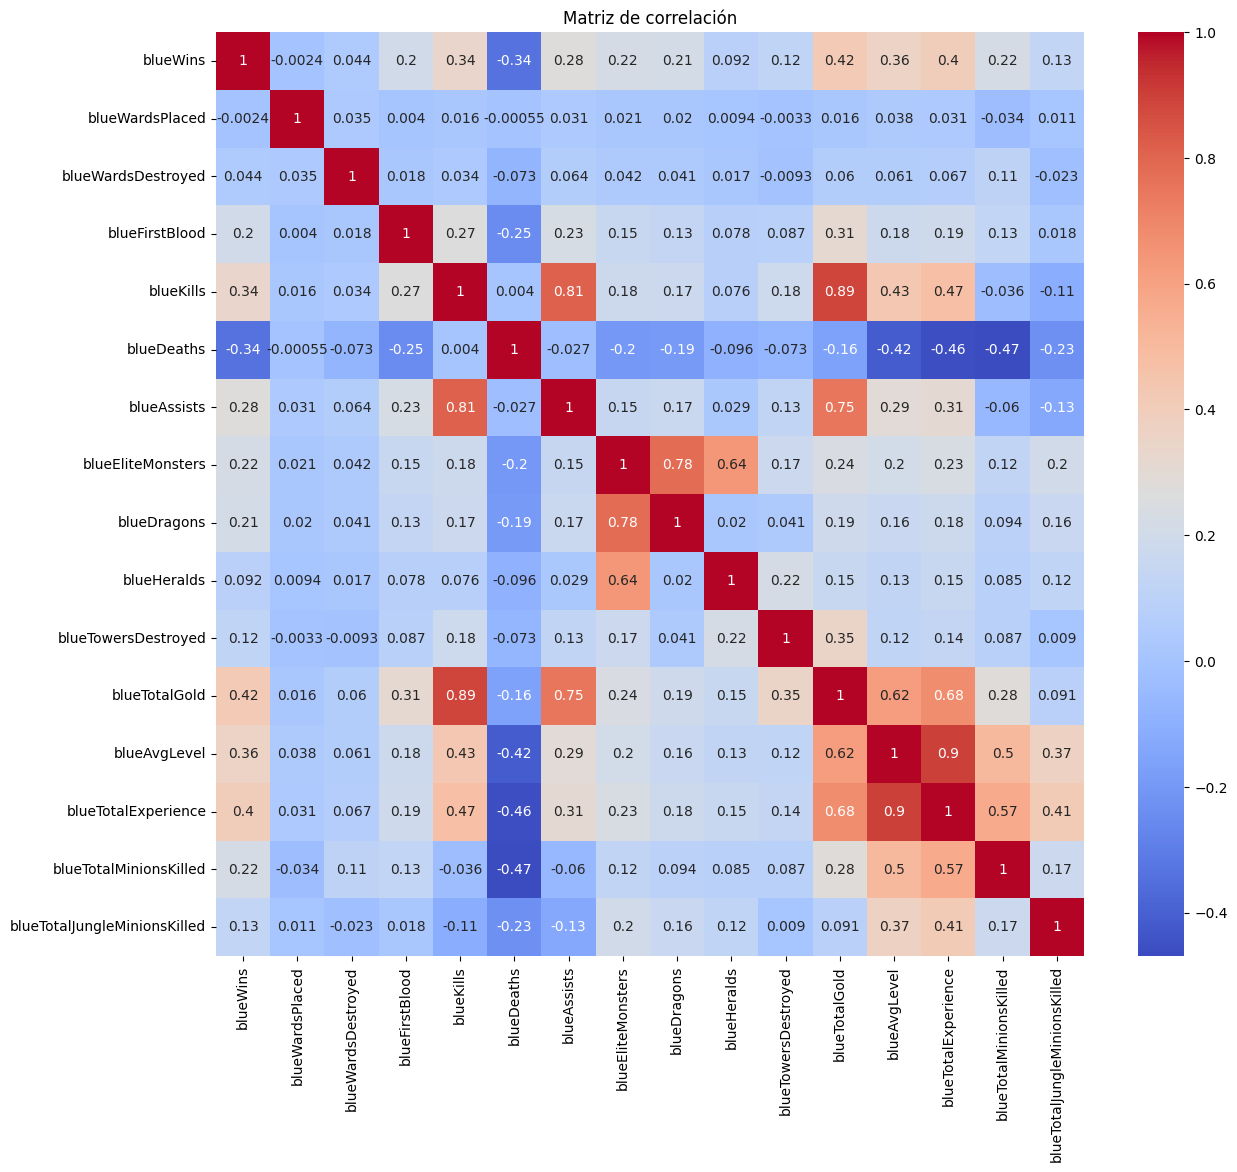

In [5]:
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# **3.0 Selección de Variables X e Y**

Inicialmente, seleccionamos blueTotalGold como variable dependiente (Y), ya que representa el rendimiento económico del equipo dentro de la partida.

Como posible variable independiente, se considera en un inicio blueTotalMinionsKilled, debido a que eliminar Minions es una acción constante y relativamente accesible para los jugadores durante la partida.

Sin embargo, al analizar la matriz de correlación, se observa que blueTotalMinionsKilled presenta una correlación baja con blueTotalGold (≈ 0.28), lo que indica una relación débil.

Por otro lado, la variable blueKills presenta la correlación más alta con blueTotalGold siendo de (≈ 0.89), evidenciando una relación positiva fuerte.

En base a estos resultados, se descarta el uso de blueTotalMinionsKilled y se selecciona blueKills como variable independiente (X), ya que nos permite explicar de mejor manera el comportamiento de la variable dependiente y no cuenta con valores nulos.

# **4.0 Gráfico de dispersión**

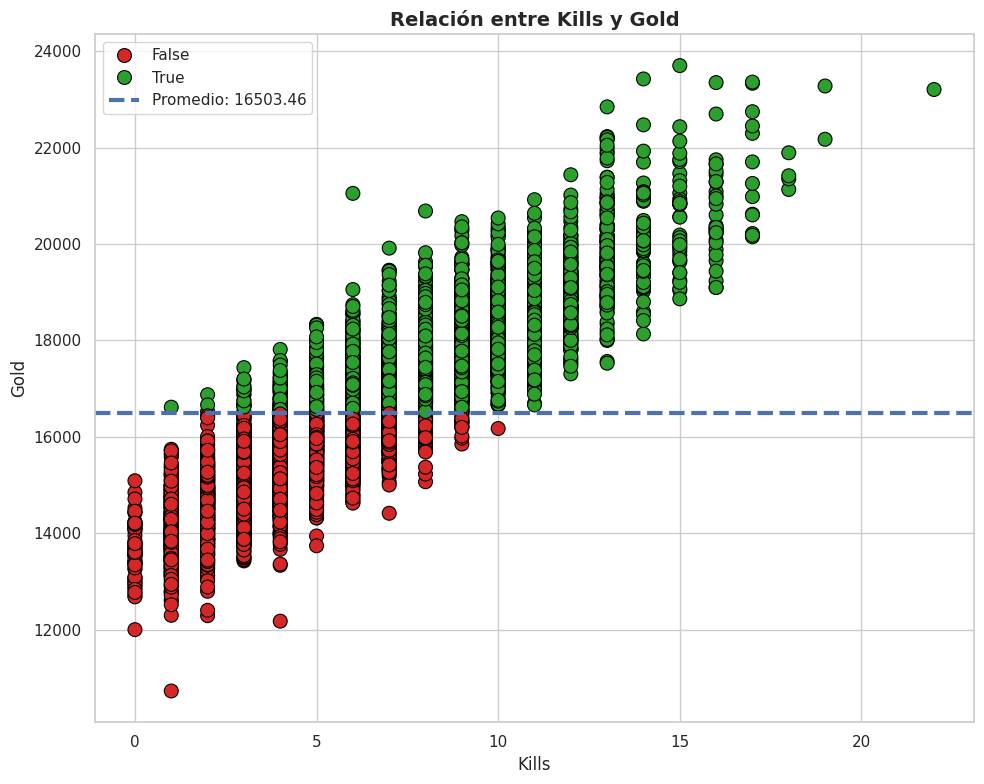

In [6]:
# Importamos librerías
import matplotlib.pyplot as plt
import seaborn as sns

# Ajuste de estilo: aplicamos una cuadrícula blanca de fondo para mejor legibilidad
sns.set_theme(style="whitegrid", context="notebook")

# Calculamos el promedio de oro y creamos una columna binaria (True/False)
# para clasificar quién supera ese promedio.
promedio_gold = df["blueTotalGold"].mean()
df["above_average"] = df["blueTotalGold"] > promedio_gold

# Tamaño del gráfico
plt.figure(figsize=(10,8))

# Gráfico mejorado:
sns.scatterplot(
    data=df,
    x="blueKills",
    y="blueTotalGold",
    s=100,             # 's' aumenta el tamaño de los puntos para que se vean mejor
    hue="above_average", # 'hue' asigna colores diferentes según la columna creada (True/False)
    palette={True: "#2ca02c", False: "#d62728"}, # Verde para sobre el promedio, Rojo para debajo
    edgecolor="black", # Borde negro para dar contraste a cada punto
    legend='full'       # Muestra la leyenda completa con los colores

)
# Dibujamos una línea horizontal en el promedio. Es un "ancla" visual para comparar.
plt.axhline(promedio_gold, linestyle="--", linewidth=3, label=f'Promedio: {promedio_gold:.2f}')

plt.title("Relación entre Kills y Gold", fontsize=14, weight="bold")
plt.xlabel("Kills")
plt.ylabel("Gold")

# Elimina espacios en blanco innecesarios alrededor del gráfico y lo mostramos
plt.legend()
plt.tight_layout()
plt.show()

## **4.1 Interpretación del Gráfico**

Al observar el gráfico de dispersión, se aprecia una relación clara entre las variables.

La relación es positiva: A medida que aumenta el número de kills, el oro total  tiende a aumentar.

La nube de puntos presenta una forma aproximadamente lineal, lo que sugiere que un modelo de regresión lineal es adecuado.

Sin embargo, se observa cierta dispersión vertical en los datos, lo que indica que existen otros factores que también influyen en el oro total, además de las kills.

# **5.0 Cálculo de Correlación**

In [7]:
#Cálculo
correlacion = df["blueKills"].corr(df["blueTotalGold"])
print("Correlación:", correlacion)

Correlación: 0.888750863655206


El coeficiente de correlación es aproximadamente 0.89 (visto en la matriz de correlación), lo que indica una relación lineal positiva fuerte.

Esto significa que existe una asociación consistente: valores altos de kills tienden a corresponder con valores altos de totalGold.

Sin embargo, es importante no sobreinterpretar:

*   No implica causalidad directa
*   No implica que kills explique todo el comportamiento del gold


El valor alto es coherente con el gráfico, donde se observaba una tendencia creciente clara.

Como punto clave a mencionar: la correlación alta confirma la dirección y fuerza de la relación, pero no elimina la variabilidad observada.

# **6.0 Definimos variables X e Y**

Antes de entrenar el modelo, debemos dejar explícito qué variable queremos **explicar o predecir** y cuál variable usaremos como **entrada**.

En este modelo:

- `X` será la **variable independiente** o explicativa: **blueKills**
- `y` será la **variable objetivo** o dependiente: **blueTotalGold**

La idea es sencilla: queremos analizar cómo cambian el oro total del equipo azul en función de las kills del equipo.

In [14]:
# Regresión Lineal OLS
X = df[["blueKills"]]
y = df["blueTotalGold"]

# **7.0 Modelo OLS**

Partiremos creando el modelo.

In [12]:
# Importamos de la biblioteca estándar sklearn en el submódulo linear modeal, la clase LinearRegression
from sklearn.linear_model import LinearRegression

# Creamos una instancia de la clase para entrenarla
modelo = LinearRegression()

## **7.1 Entrenar modelo con FIT**

Ahora le pedimos al modelo que aprenda la relación entre la variable de entrada y la variable de salida.

In [15]:
#Ejecutamos fit, para que el modelo aprenda los valores X e Y
modelo.fit(X, y)

LinearRegression()

El modelo aprende dos valores importantes:


1. La **pendiente**, que indica cuánto cambia y cuando cambia X.
2. El **intercepto**, que indica el valor inicial de la recta.



*   *fit encontrará la ecuación de la recta que mejor se ajusta a los datos.*





## **7.2 Obtenemos los Coeficientes**

In [16]:
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

print("Pendiente:", pendiente)
print("Intercepto:", intercepto)

Pendiente: 453.2105099274729
Intercepto: 13700.835483148168


El modelo ajusta una recta minimizando el error cuadrático total.

*   Pendiente: representa el cambio promedio en el gold por cada kill adicional
*   Intercepto: el valor esperado de gold cuando kills = 0




## **7.3 Calculamos las predicciones**

Después de entrenar el modelo, usamos predict(X) para obtener los valores estimados por la regresión lineal. Es decir, el modelo toma cada valor de **blueKills** y calcula cuál sería el **blueTotalGold** esperado según la recta de regresión que aprendió

Esos resultados quedan guardados en y_pred.

In [18]:
# Predicciones
y_pred = modelo.predict(X)

# 8.0 Recta de Regresión (Gráficar resultados)

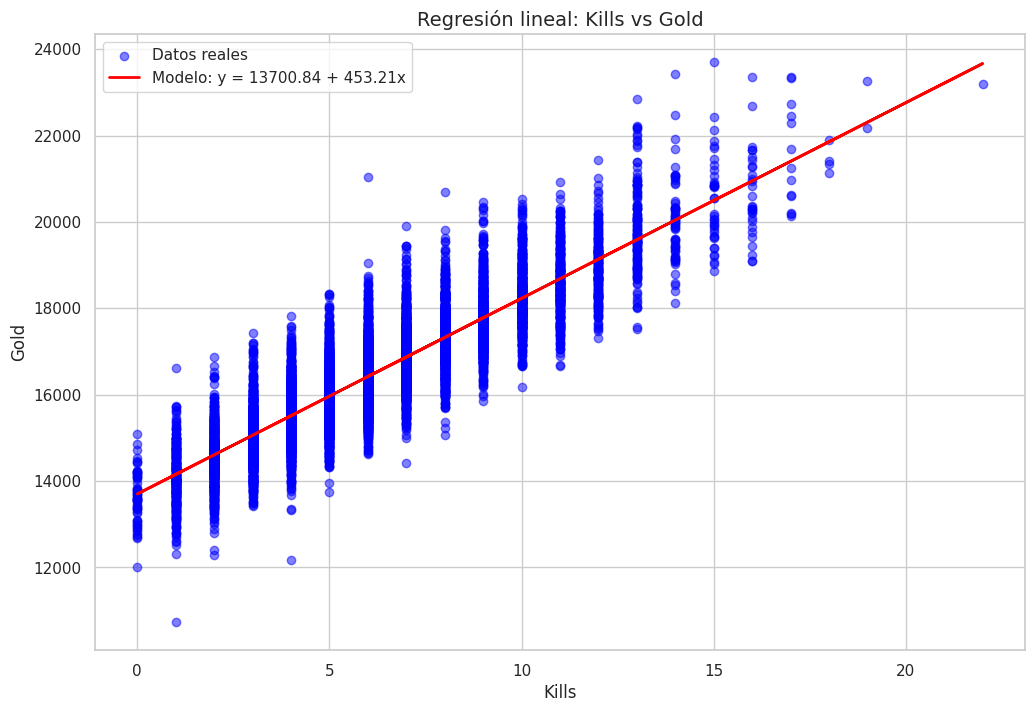

Ecuación del modelo: Oro = 13700.84 + 453.21 * Kills


In [26]:
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(12, 8))

# Graficamos los datos reales (los puntos azules)
plt.scatter(X, y, color="blue", alpha=0.5, label="Datos reales")

# Graficamos la recta de regresión (la línea roja) y ponemos la ecuación
plt.plot(X, y_pred, color="red", linewidth=2, label=f"Modelo: y = {intercepto:.2f} + {pendiente:.2f}x")

# Títulos y nombres de los ejes
plt.title("Regresión lineal: Kills vs Gold", fontsize=14)
plt.xlabel("Kills")
plt.ylabel("Gold")



# Mostramos la leyenda y grafico final
plt.legend()
plt.show()

# Imprimimos la ecuación en consola para tenerla como texto
print(f"Ecuación del modelo: Oro = {intercepto:.2f} + {pendiente:.2f} * Kills")

La ecuación del modelo tiene la forma **y = b0 + b1(x)\, donde:**


*   b0 (intercepto): Representa el oro estimado cuando los kills son 0.

***Aunque matemáticamente es válido, en la práctica puede no tener una interpretación completamente realista dentro del juego.***

*   b1 (pendiente): Indica cuánto aumenta el oro en promedio por cada kill adicional.

***Este valor tiene una interpretación directa: refleja el impacto económico de las eliminaciones en el equipo.***

La recta se ajusta adecuadamente a la tendencia general de los datos, aunque no pasa por todos los puntos, lo que es esperable en un modelo de regresión.

NOTA: La distancia entre los puntos reales y la recta representa el error del modelo.

👉 el modelo es una aproximación, no una descripción exacta.





# **9.0 Cálculo de Métricas**

In [27]:
# Métricas de evaluación
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

#Crear tabla de resultados
metrics_dfe = pd.DataFrame({
    "MSE": [mse],
    "RMSE": [rmse],
    "MAE": [mae],
    "R^2": [r2]
})

metrics_dfe

,MSE,RMSE,MAE,R^2
0,495332.489849,703.798615,548.1871,0.789878


**Explicación de métricas:**

MSE: 495,332

- Es el error cuadrático medio. Penaliza más los errores grandes, por lo que ayuda a detectar desviaciones importantes, aunque su valor debe interpretarse considerando la escala del gold.

RMSE: 703.80

- Indica que el modelo se equivoca en promedio en unos 700 de oro por predicción. Dado que el gold total suele ser mucho mayor, el error es relativamente bajo.

MAE: 548.19

- Es el error promedio absoluto. Muestra que las predicciones se desvían aproximadamente 548 de oro, lo que confirma un error moderado.

R²: 0.7899

- Indica que el modelo explica cerca del 79% de la variabilidad del oro, lo que representa un buen nivel de ajuste para un modelo simple.

# **10.0 Interpretación de resultados**

**¿Qué relación se encontró entre las variables?**
- Se encontró una relación positiva fuerte entre las kills y el oro total. En general, cuando aumentan las kills, el oro también aumenta. Esto se ve tanto en el gráfico como en la correlación (~0.89), lo que muestra una relación bastante clara.

**¿La recta parece representar razonablemente los datos?**
- Sí, la recta representa bien la tendencia general. La mayoría de los puntos están cerca, aunque hay dispersión cuando hay la misma cantidad de kills, lo que indica que no todo el oro se explica solo con esta variable.

**¿Las métricas muestran un buen ajuste o un ajuste débil?**
- El modelo tiene un buen ajuste. El R² ≈ 0.79 indica que cerca del 79% del comportamiento del oro se explica por los kills. El RMSE ≈ 700 muestra que hay error, pero considerando los valores de oro, sigue siendo aceptable.

**¿Tiene sentido práctico el modelo obtenido?**
- Sí, tiene sentido práctico, ya que los kills generan recompensas económicas dentro del juego, lo que explica la relación observada y permite estimar el oro de forma aproximada.

**¿Qué limitaciones observa en este análisis?**
- El modelo tiene limitaciones. Solo usa una variable y deja fuera otras importantes como minions u objetivos. También asume una relación lineal, lo que simplifica la realidad.
Además, aunque el dataset tiene variables con nulos, las variables usadas no los tienen, lo que permitió trabajar con datos completos. Esto es positivo, pero también significa que se dejaron fuera otras variables que podrían aportar información.
Finalmente, la dispersión muestra que el modelo no explica todo el comportamiento del oro.